Carregando o arquivo df_full.csv...
Formato do DataFrame: (66540, 15)

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66540 entries, 0 to 66539
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    66540 non-null  object 
 1   S1_1         66540 non-null  float64
 2   S1_2         66540 non-null  float64
 3   S1_3         66540 non-null  float64
 4   S1_4         66540 non-null  float64
 5   S1_5         66540 non-null  float64
 6   S1_6         66540 non-null  float64
 7   S2_1         66540 non-null  float64
 8   S2_2         66540 non-null  float64
 9   S3_1         66540 non-null  float64
 10  S3_2         66540 non-null  float64
 11  S4_1         66540 non-null  float64
 12  S4_2         66540 non-null  float64
 13  Nivel_agua   66540 non-null  float64
 14  Nivel_total  66540 non-null  float64
dtypes: float64(14), object(1)
memory usage: 7.6+ MB

Verificando valores nulos:

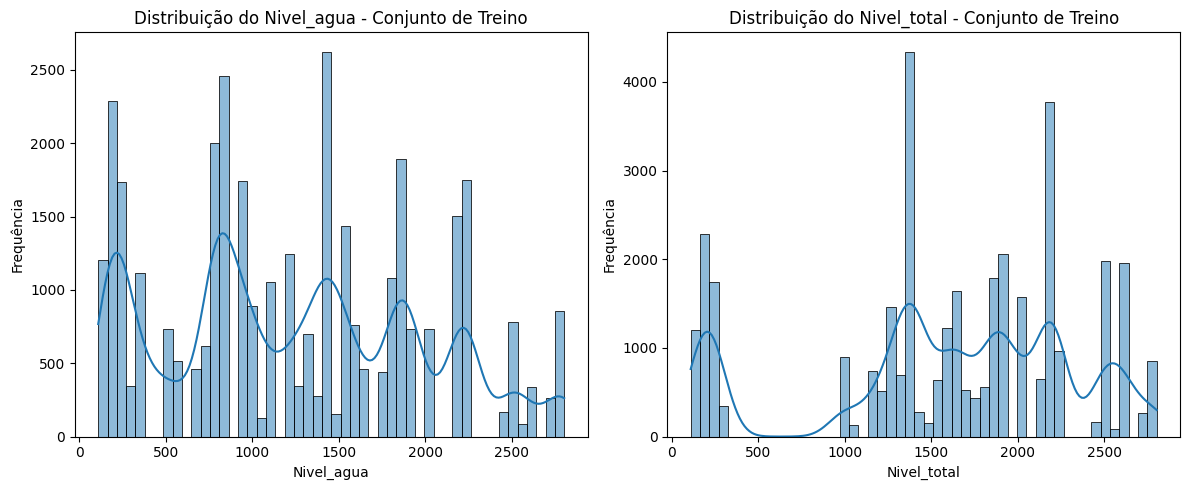

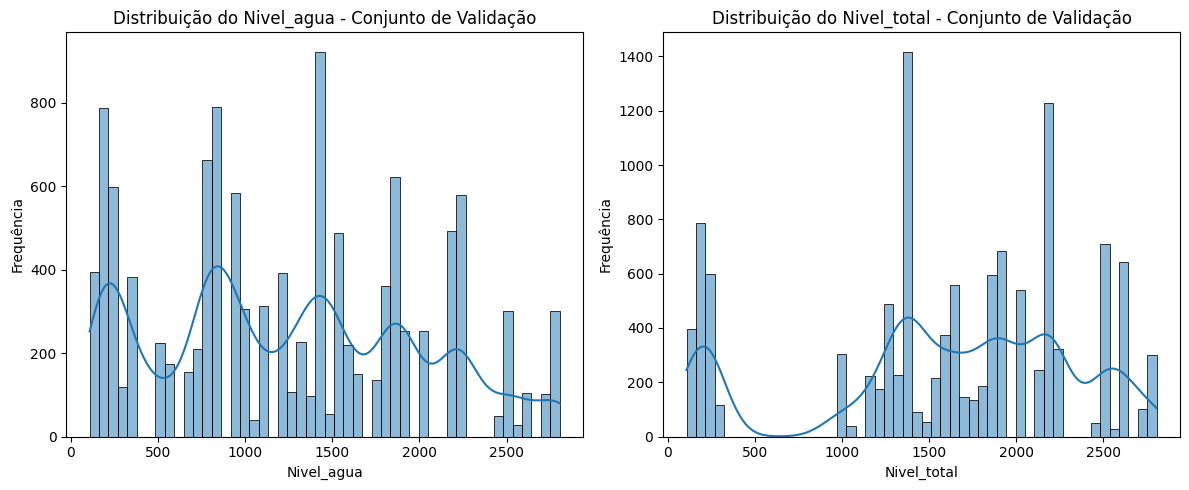

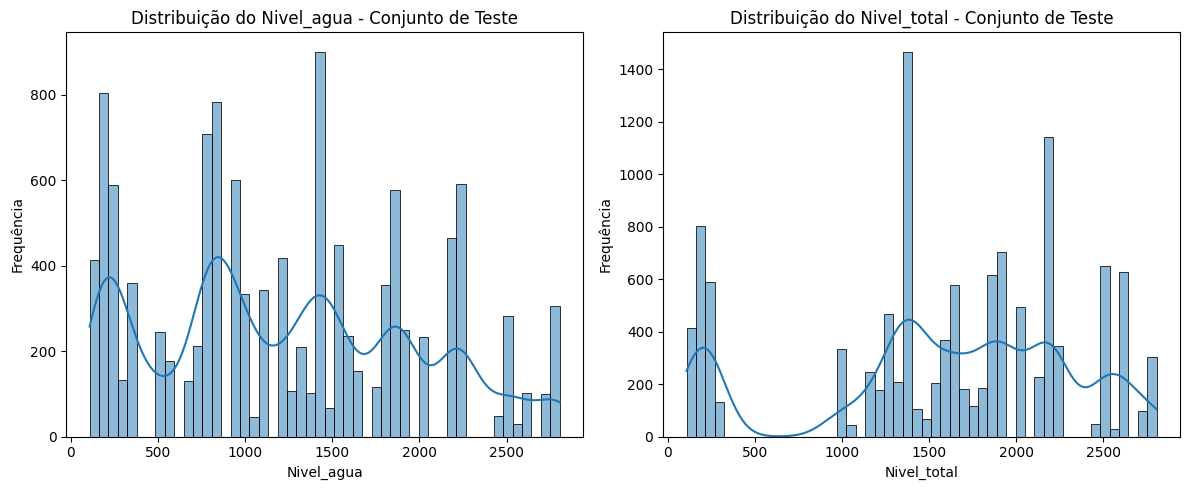

Estatísticas descritivas do Nivel_agua e Nivel_total no treino:
          Nivel_agua   Nivel_total
count  35931.000000  35931.000000
mean    1244.425900   1597.814255
std      732.947606    741.375232
min      109.000000    109.000000
25%      746.000000   1287.000000
50%     1219.000000   1656.000000
75%     1848.000000   2188.000000
max     2804.000000   2804.000000

Estatísticas descritivas do Nivel_agua e Nivel_total na validação:
          Nivel_agua   Nivel_total
count  11977.000000  11977.000000
mean    1248.152542   1599.428571
std      740.332208    749.158363
min      109.000000    109.000000
25%      746.000000   1287.000000
50%     1232.000000   1656.000000
75%     1880.000000   2188.000000
max     2804.000000   2804.000000

Estatísticas descritivas do Nivel_agua e Nivel_total no teste:
          Nivel_agua   Nivel_total
count  11978.000000  11978.000000
mean    1234.571548   1582.641760
std      738.356298    749.349666
min      109.000000    109.000000
25%      746.000000

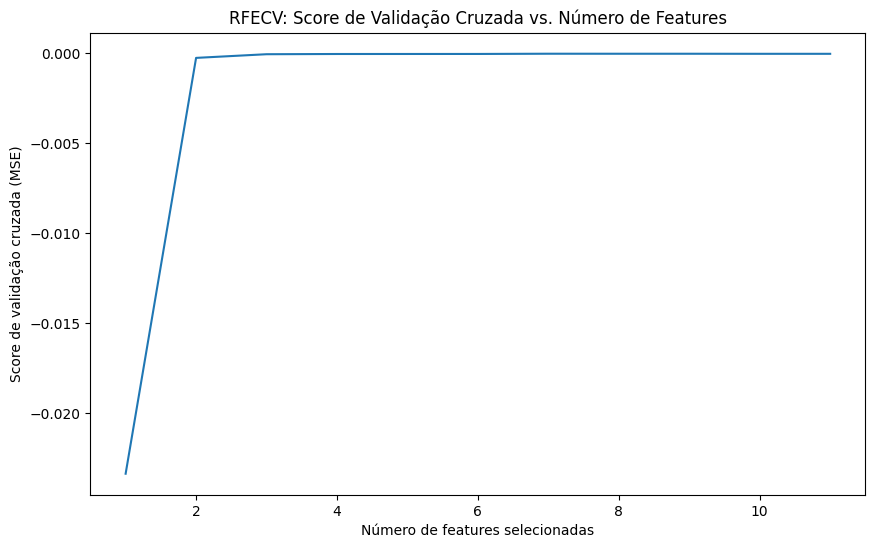


Forma dos conjuntos de dados após a seleção de features:
X_train_selected: (35931, 7)
X_val_selected: (11977, 7)
X_test_selected: (11978, 7)

Salvando conjuntos de dados escalonados e com features selecionadas...
Conjuntos de dados salvos com sucesso (.npy).


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold   
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
# ==============================================================================

# Passo 1: Carregamento e Checagem Inicial dos Dados
# a) Crie um novo notebook e nomeie-o como 02-PreProcessamento;
# b) Carregue o arquivo df_full.csv;
print("Carregando o arquivo df_full.csv...")
df = pd.read_csv('../data/brute/df_full.csv')

# c) Faça uma checagem básica
print("Formato do DataFrame:", df.shape)
print("\nInformações do DataFrame:")
df.info()
print("\nVerificando valores nulos:")
print(df.isnull().sum())
print("\nVerificando valores duplicados:", df.duplicated().sum())

# Removendo colunas que não serão utilizadas no modelo
# Com base na sua análise, o sensor S4_2 está com defeito e será removido.
# A coluna 'Timestamp' também será removida por não ser uma feature para o modelo de regressão.
print("\nRemovendo as colunas 'Timestamp' e 'S4_2'...")
df_processado = df.drop(columns=['Timestamp', 'S4_2'])
print("Colunas removidas com sucesso.")

# Passo 2: Tratamento de Outliers
# a) Detecte outliers com o algoritmo Local Outlier Factor (LOF);
#    a. Configure 20 vizinhos.
#    b. Defina a proporção de outliers esperada, como 5% ou 10%.
print("\nIniciando a detecção e tratamento de outliers com LOF...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1) # Utilizando 10% de contaminação

# Identificando as colunas dos sensores para a detecção de outliers
sensor_cols = [col for col in df_processado.columns if col.startswith('S')]
X_sensors = df_processado[sensor_cols]

# Realizando a predição dos outliers
outliers = lof.fit_predict(X_sensors)

# b) Crie uma cópia da base sem os outliers, para utilizar no restante do processo.
df_sem_outliers = df_processado[outliers == 1]
print(f"Número de outliers removidos: {df_processado.shape[0] - df_sem_outliers.shape[0]}")
print(f"Novo formato do DataFrame sem outliers: {df_sem_outliers.shape}")



# ==============================================================================
#- DETECÇÃO DE OUTLIERS COM LOF
# ==============================================================================
print("\nIniciando a detecção e tratamento de outliers com LOF...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

sensor_cols = [col for col in df_processado.columns if col.startswith('S')]
X_sensors = df_processado[sensor_cols]

outliers = lof.fit_predict(X_sensors)

# Mantendo apenas os dados normais
df_sem_outliers = df_processado[outliers == 1]

print(f"Número de outliers removidos: {df_processado.shape[0] - df_sem_outliers.shape[0]}")
print(f"Novo formato do DataFrame sem outliers: {df_sem_outliers.shape}")

# ==============================================================================
#- DIVISÃO EM TREINO / VALIDAÇÃO / TESTE
# ==============================================================================
print("\nDividindo a base de dados em treino, validação e teste...")

X = df_sem_outliers.drop(columns=['Nivel_agua', 'Nivel_total'])
y = df_sem_outliers[['Nivel_agua', 'Nivel_total']]

X_treino, X_temp, y_treino, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_teste, y_val, y_teste = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Divisão concluída com sucesso!")
print(f"Tamanho do conjunto de treino: {X_treino.shape[0]} amostras")
print(f"Tamanho do conjunto de validação: {X_val.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_teste.shape[0]} amostras")

if y_treino is not None and y_val is not None and y_teste is not None:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Função para plotar a distribuição dos níveis
    def plot_nivel_distribution(y_data, title):
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(y_data['Nivel_agua'], bins=50, kde=True)
        plt.title(f'Distribuição do Nivel_agua - {title}')
        plt.xlabel('Nivel_agua')
        plt.ylabel('Frequência')

        plt.subplot(1, 2, 2)
        sns.histplot(y_data['Nivel_total'], bins=50, kde=True)
        plt.title(f'Distribuição do Nivel_total - {title}')
        plt.xlabel('Nivel_total')
        plt.ylabel('Frequência')

        plt.tight_layout()
        plt.show()

    # Plotar a distribuição nos conjuntos de treino, validação e teste
    plot_nivel_distribution(y_treino, 'Conjunto de Treino')
    plot_nivel_distribution(y_val, 'Conjunto de Validação')
    plot_nivel_distribution(y_teste, 'Conjunto de Teste')

    # Opcional: Exibir estatísticas descritivas dos níveis em cada conjunto
    print("Estatísticas descritivas do Nivel_agua e Nivel_total no treino:\n", y_treino.describe())
    print("\nEstatísticas descritivas do Nivel_agua e Nivel_total na validação:\n", y_val.describe())
    print("\nEstatísticas descritivas do Nivel_agua e Nivel_total no teste:\n", y_teste.describe())
else:
    print("Conjuntos de treino, validação ou teste não disponíveis. Pulando a verificação de distribuição.")
    
    # ==============================================================================
#- Passo 5: Normalização / Scaling
#- Colocar todas as variáveis (sensores e targets) na mesma escala usando o
#- MinMaxScaler.
# ==============================================================================
if X_treino is not None and y_treino is not None:
    from sklearn.preprocessing import MinMaxScaler
    import joblib # Para salvar os scalers

    # Inicializar os scalers para features (X) e targets (y)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

   # Ajustar (fit) e transformar os dados de treino
    X_treino_scaled = scaler_X.fit_transform(X_treino)
    y_treino_scaled = scaler_y.fit_transform(y_treino)

# Transformar validação e teste usando o scaler ajustado no treino
    X_val_scaled   = scaler_X.transform(X_val)
    y_val_scaled   = scaler_y.transform(y_val)   # corrigido aqui!

    X_teste_scaled = scaler_X.transform(X_teste)
    y_teste_scaled = scaler_y.transform(y_teste)


    # Opcional: Exibir as primeiras linhas dos dados normalizados
    print("Primeiras linhas de X_treino_scaled:\n", X_treino_scaled[:5])
    print("\nPrimeiras linhas de y_treino_scaled:\n", y_treino_scaled[:5])


    # Salvar os scalers para uso futuro
    try:
        joblib.dump(scaler_X, 'scaler_X.pkl')
        joblib.dump(scaler_y, 'scaler_y.pkl')
        print("\nScalers salvos como 'scaler_X.pkl' e 'scaler_y.pkl'")
    except Exception as e:
        print(f"Erro ao salvar scalers: {e}")

else:
    print("Conjuntos de treino ou teste não disponíveis. Pulando a normalização.")
    X_treino_scaled, X_val_scaled, X_teste_scaled, y_treino_scaled, y_val_scaled, y_teste_scaled = None, None, None, None, None, None # Definir variáveis como None
    scaler_X, scaler_y = None, None # Definir scalers como None
    
    # ==============================================================================
#- Passo 6: Seleção de Features com RFECV
#- Utilizado o RFECV com um modelo Random Forest para selecionar as features
#- mais relevantes.
# ==============================================================================
if X_treino_scaled is not None and y_treino_scaled is not None:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.feature_selection import RFECV
    from sklearn.model_selection import KFold
    import matplotlib.pyplot as plt
    import numpy as np # Importar numpy para salvar arrays

    # Definido o modelo base para o RFECV
    # Usado um Random Forest Regressor
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # Ajuste n_estimators e adicione n_jobs para paralelismo

    # Configuraração do RFECV
    # step=1: remove 1 feature por iteração
    # cv=5: utiliza validação cruzada com 5 folds
    min_features_to_select = 1 # Número mínimo de features a serem selecionadas
    rfecv = RFECV(
        estimator=model,
        step=1,
        cv=KFold(5), # Usando KFold para cross-validation
        scoring='neg_mean_squared_error', # Métrica de avaliação para regressão
        min_features_to_select=min_features_to_select,
        n_jobs=-1 # Usar todos os núcleos disponíveis
    )

    # Executa o RFECV nos dados de treino escalonados
    rfecv.fit(X_treino_scaled, y_treino_scaled)

    print("Número ideal de features:", rfecv.n_features_)
    print("Máscara de features selecionadas:", rfecv.support_)
    print("Ranking de features:", rfecv.ranking_)

    try:
        # Usa as colunas do dataframe filtrado original ou novo, se disponível
        if 'df_filtered_novo' in locals() and df_filtered_novo is not None:
             original_features = df_filtered_novo.drop(['Timestamp', 'Nivel_agua', 'Nivel_total'], axis=1).columns
        elif 'df_filtered' in locals() and df_filtered is not None:
             original_features = df_filtered.drop(['Timestamp', 'Nivel_agua', 'Nivel_total'], axis=1).columns
        else:
             # Fallback: Usa as colunas do dataframe processado se nada filtrado estiver disponível
             original_features = df_processado.drop(['Nivel_agua', 'Nivel_total'], axis=1).columns


        selected_features = original_features[rfecv.support_]
        print("\nFeatures selecionadas:")
        print(selected_features)
    except Exception as e:
        print(f"\nNão foi possível exibir os nomes das features selecionadas: {e}")
        print("Máscara de features selecionadas (sem nomes):", rfecv.support_)


    # Plota o score de validação cruzada em função do número de features
    plt.figure(figsize=(10, 6))
    plt.xlabel("Número de features selecionadas")
    plt.ylabel("Score de validação cruzada (MSE)")
    # rfecv.cv_results_['mean_test_score'] contém os scores médios para cada número de features
    # O número de features correspondente ao índice i é (i + min_features_to_select)
    plt.plot(range(min_features_to_select, len(rfecv.cv_results_['mean_test_score']) + min_features_to_select), rfecv.cv_results_['mean_test_score'])
    plt.title("RFECV: Score de Validação Cruzada vs. Número de Features")
    plt.show()

    # Filtra os conjuntos de dados para conter apenas as features selecionadas
    X_train_selected = X_treino_scaled[:, rfecv.support_]
    X_val_selected = X_val_scaled[:, rfecv.support_]
    X_test_selected = X_teste_scaled[:, rfecv.support_]

    print("\nForma dos conjuntos de dados após a seleção de features:")
    print("X_train_selected:", X_train_selected.shape)
    print("X_val_selected:", X_val_selected.shape)
    print("X_test_selected:", X_test_selected.shape)

    # ==============================================================================
    #- SALVAR CONJUNTOS DE DADOS SELECIONADOS E ESCALONADOS
    # ==============================================================================
    print("\nSalvando conjuntos de dados escalonados e com features selecionadas...")
    try:
        np.save('X_train_selected.npy', X_train_selected)
        np.save('X_val_selected.npy', X_val_selected)
        np.save('X_test_selected.npy', X_test_selected)
        np.save('y_treino_scaled.npy', y_treino_scaled)
        np.save('y_val_scaled.npy', y_val_scaled)
        np.save('y_teste_scaled.npy', y_teste_scaled)
        print("Conjuntos de dados salvos com sucesso (.npy).")
    except Exception as e:
        print(f"Erro ao salvar conjuntos de dados: {e}")


else:
    print("Conjuntos de dados escalonados não disponíveis. Pulando a seleção de features.")
    X_train_selected, X_val_selected, X_test_selected = None, None, None # Definir variáveis como None

In [5]:
# Salvar o DataFrame sem outliers em um arquivo CSV
df_sem_outliers.to_csv('../data/processed/df_sem_outliers.csv', index=False)
print("Arquivo 'df_sem_outliers.csv' salvo em '../data/processed/'.")

Arquivo 'df_sem_outliers.csv' salvo em '../data/processed/'.
